<a href="https://colab.research.google.com/github/Pranayshukla0610/MLFlow/blob/main/End_to_End_Customer_Churn_Prediction_System_using_Advanced_Logistic_Regression_and_Predictive_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import os
import zipfile
import pandas as pd
import hashlib

In [26]:
class DataIngestion:
  def __init__(self,zip_path,extract_path):
    self.zip_path = zip_path
    self.extract_path = extract_path

  def verify(self):
    if not os.path.exists(self.extract_path):
      raise FileNotFoundError('Zip not found')

    with open(self.zip_path, 'rb') as f:
      print('Hash:',hashlib.md5(f.read()).hexdigest())

  def extract(self):
    os.makedirs(self.extract_path, exist_ok=True)
    with zipfile.ZipFile(self.zip_path, 'r') as z:
      z.extractall(self.extract_path)

  def load(self):
    file = [f for f in os.listdir(self.extract_path) if f.endswith('.csv')][0]
    return pd.read_csv(os.path.join(self.extract_path, file))

In [27]:
ingestion = DataIngestion('/content/archive (36).zip','/content/')
ingestion.verify()
ingestion.extract()

df = ingestion.load()
df.head()

Hash: da6ec8e23689205887e9226246d3c122


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: xlabel='Churn', ylabel='count'>

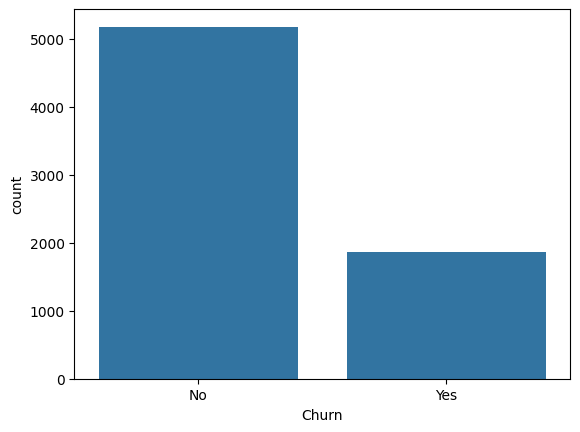

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)

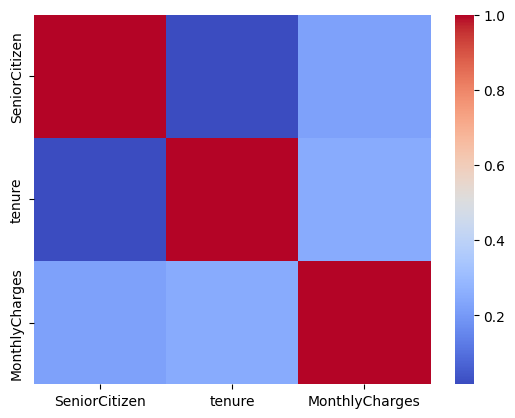

In [30]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.show()

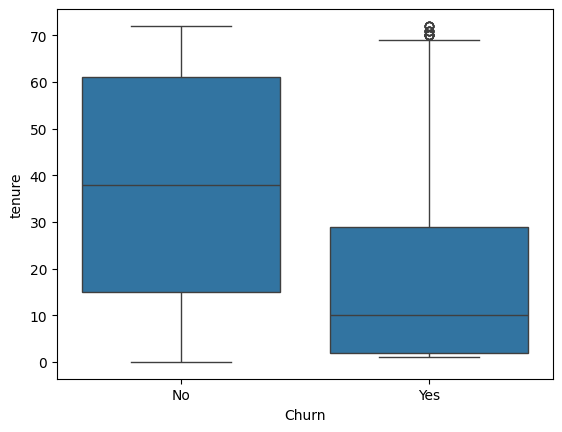

In [31]:
sns.boxplot(x='Churn', y='tenure',data=df)
plt.show()

In [32]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [33]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
num_cols = df.select_dtypes(include='number').columns

df[num_cols] = imputer.fit_transform(df[num_cols])

In [34]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [35]:
df = pd.get_dummies(df, drop_first=True)

In [36]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF',
       ...
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object', length=7073)


In [37]:
df.columns = df.columns.str.strip()

In [38]:
print([col for col in df.columns if 'charge' in col.lower()])

['MonthlyCharges', 'TotalCharges']


In [39]:
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

In [40]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgCharges
0,0.0,1.0,29.85,29.85,0.0,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,14.925000
1,0.0,34.0,56.95,1889.50,0.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,53.985714
2,0.0,2.0,53.85,108.15,1.0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,36.050000
3,0.0,45.0,42.30,1840.75,0.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,40.016304
4,0.0,2.0,70.70,151.65,1.0,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,50.550000


In [41]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
X_train.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,10
customerID_0003-MKNFE,0
...,...
PaperlessBilling_Yes,0
PaymentMethod_Credit card (automatic),0
PaymentMethod_Electronic check,0
PaymentMethod_Mailed check,0


In [47]:
impute = SimpleImputer(strategy='median')
X_train = impute.fit_transform(X_train)
X_test = impute.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [49]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[935 101]
 [168 205]]


In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.85      0.90      0.87      1036
         1.0       0.67      0.55      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [53]:
from sklearn.metrics import roc_auc_score
print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.8613156914095252


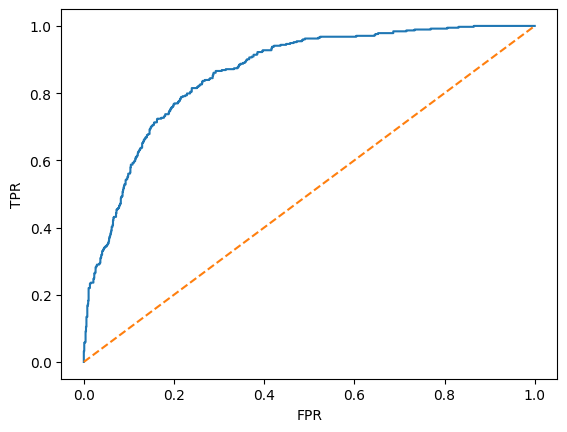

In [54]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [55]:
model = LogisticRegression(class_weight='balanced')

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [57]:
import joblib
joblib.dump(pipeline, "model.pkl")

['model.pkl']

In [58]:
def predict(input_df):
    model = joblib.load("model.pkl")
    return model.predict(input_df)